# 81 — spectrogram representation playground (gastronorm, src3)

Explore different ways to turn a gastronorm sample's `vibration/04_fft.npz` into the 2D
map that `src3` feeds to BEATs, so it isn't mostly black and actually shows structure.

**How this map reaches the model (`src3/beats_input.py`):** `spectrogram_map()` builds a
`(F, T)` float32 log-magnitude STFT (or `laser_freq_map()` builds `(F, L)` from the raw FFT
heatmap) → `to_beats_fbank()` bilinear-resizes the freq axis to 128 bins, transposes to
`(T, 128)`, and z-score normalizes it → fed as a **single-channel** `(B, 1, T, 128)` tensor
into BEATs' `patch_embedding`, which is a `Conv2d(1, embed_dim, ...)` — it literally only
accepts 1 input channel.

**So: black & white or color?** The model never sees color — it only ever sees this one
float channel. The "image" you see in wandb (`map_to_image`) is a `uint8` array rendered
purely for *us* to look at; it has zero effect on training. That means the colormap/contrast
choice below is 100% a human-legibility question, not a modeling one — pick whatever makes
structure easiest to see. A perceptually-uniform colormap (`magma`/`viridis`) will generally
reveal structure a plain grayscale render hides, especially given how skewed this data's
energy distribution is (see below).

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().resolve()
while not (REPO / "src3").exists():
    REPO = REPO.parent
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))
if str(REPO / "src") not in sys.path: sys.path.insert(0, str(REPO / "src"))

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample

from src2.data import collect, find_fft, BOX_DIRS
from src3.beats_input import laser_freq_map, spectrogram_map, map_to_image, _load_fft, LOG_CONTRAST_K
from data.vibrate import MIN_FREQ, MAX_FREQ

print(REPO)
print("MIN_FREQ, MAX_FREQ:", MIN_FREQ, MAX_FREQ)

/home/ethantu/workspace/good-vibrations
MIN_FREQ, MAX_FREQ: 50 1000


## 1. Pick a few samples

One empty-box sample and one single-cube (`purple-cube`) sample, so we can eyeball whether
the representation even changes when an object is added — if it doesn't, no amount of
contrast tweaking will help the model.

In [2]:
samples = collect("gastronorm", limit=None)
empty = next(s for s in samples if s[1].get("layout") == "empty-box")
cube = next(s for s in samples if s[1].get("n_objects") == 1)
print("empty:", empty[0].name, empty[1].get("layout"))
print("cube :", cube[0].name, cube[1].get("layout"), cube[1].get("position_id"))

empty_dir, empty_meta = empty
cube_dir, cube_meta = cube
fps = float(cube_meta["fps"])
print("fps:", fps)

empty: 000010 empty-box
cube : 000041 purple-cube 6
fps: 2500.0


## 2. Raw FFT stats

Sanity check the raw magnitude distribution before any contrast stretching — this is *why*
a plain min/max stretch goes black (a tiny number of bins dominate).

In [3]:
fft, freqs, n_samples = _load_fft(find_fft(cube_dir))
mag = np.abs(fft).mean(axis=-1)  # (L, F)
print("fft shape (L,F,C):", fft.shape, "freqs:", freqs.shape, "n_samples:", n_samples)
print("mag  min/mean/median/99th pct/max:",
      mag.min(), mag.mean(), np.median(mag), np.percentile(mag, 99), mag.max())
print(f"fraction of bins within 1% of max: {(mag > 0.99*mag.max()).mean():.4%}")

fft shape (L,F,C): (100, 1235, 2) freqs: (1235,) n_samples: 3250
mag  min/mean/median/99th pct/max: 0.002782601 0.6506014 0.2257751 5.6363335 25.368176
fraction of bins within 1% of max: 0.0008%


## 3. Current pipeline's two condition maps, side by side

`laser_freq_map` (freq x laser, from the raw FFT heatmap) vs `spectrogram_map` (freq x time,
recovered audio -> real STFT), for the same cube sample, using the *current* `map_to_image`
(1st/99.5th percentile stretch — the fix already applied in `src3/beats_input.py`).

laser_freq_map: (1235, 100) float32
spectrogram_map: (1025, 83) float32


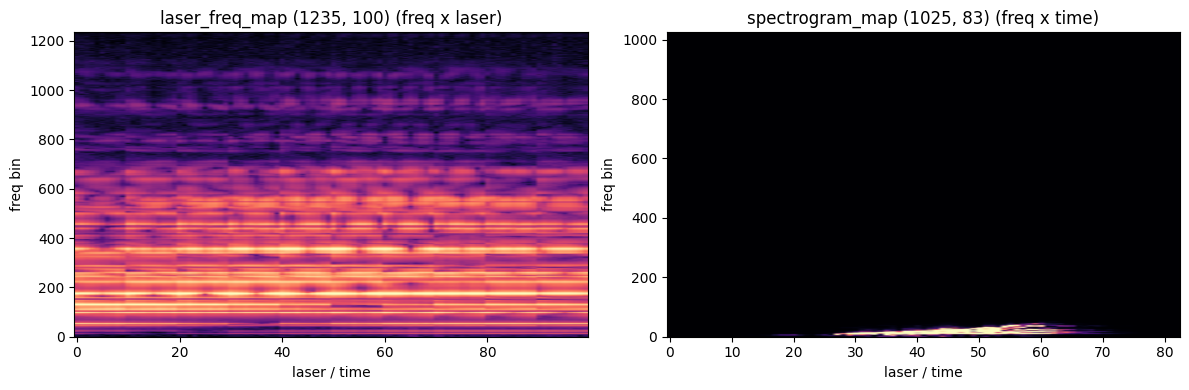

In [4]:
lf = laser_freq_map(find_fft(cube_dir))
sm = spectrogram_map(find_fft(cube_dir), fps=fps)
print("laser_freq_map:", lf.shape, lf.dtype)
print("spectrogram_map:", sm.shape, sm.dtype)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(map_to_image(lf), cmap="magma", aspect="auto", origin="lower")
axes[0].set_title(f"laser_freq_map {lf.shape} (freq x laser)")
axes[1].imshow(map_to_image(sm), cmap="magma", aspect="auto", origin="lower")
axes[1].set_title(f"spectrogram_map {sm.shape} (freq x time)")
for ax in axes: ax.set_xlabel("laser / time"); ax.set_ylabel("freq bin")
plt.tight_layout(); plt.show()

## 4. Empty box vs cube — does the map even change?

If these look identical, the representation (or the averaging-over-lasers step) is throwing
away the signal that distinguishes "cube present" from "empty".

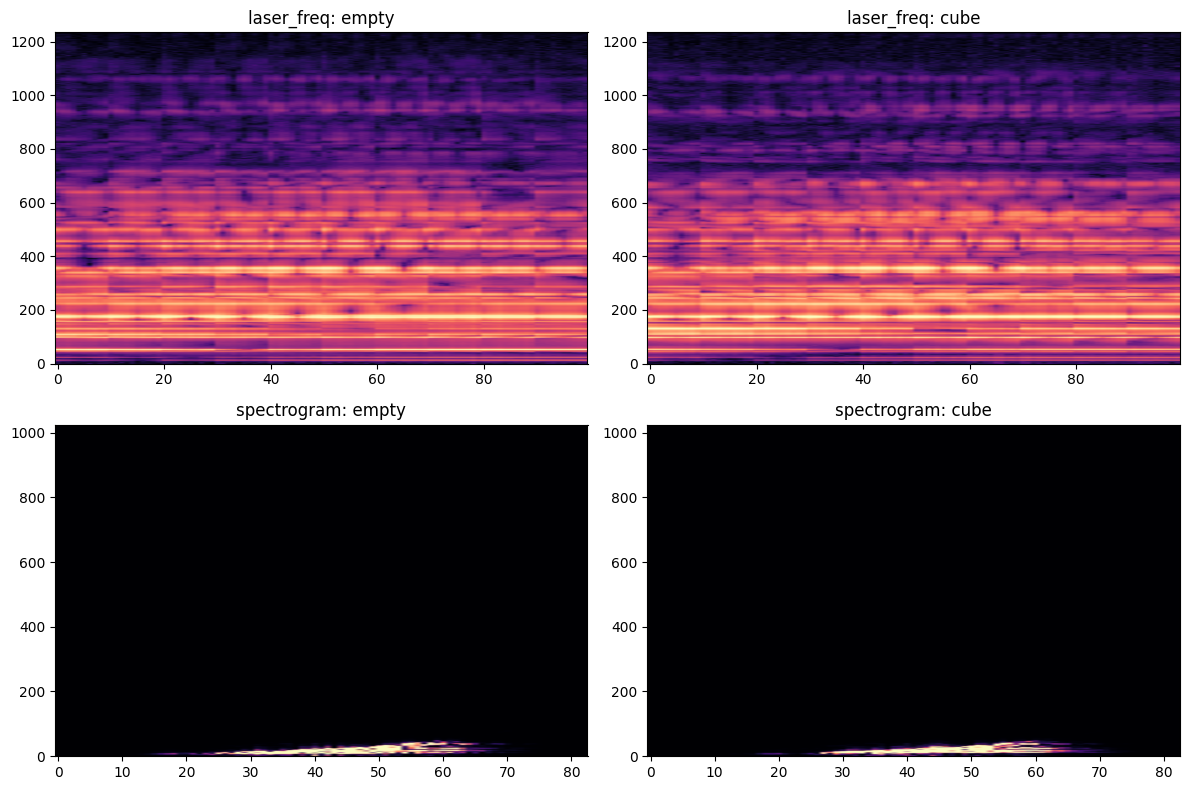

spectrogram_map |cube - empty|: mean=0.0000 max=0.0024 (relative to cube's own mean 0.0000)


In [5]:
sm_empty = spectrogram_map(find_fft(empty_dir), fps=float(empty_meta["fps"]))
lf_empty = laser_freq_map(find_fft(empty_dir))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].imshow(map_to_image(lf_empty), cmap="magma", aspect="auto", origin="lower"); axes[0,0].set_title("laser_freq: empty")
axes[0,1].imshow(map_to_image(lf), cmap="magma", aspect="auto", origin="lower"); axes[0,1].set_title("laser_freq: cube")
axes[1,0].imshow(map_to_image(sm_empty), cmap="magma", aspect="auto", origin="lower"); axes[1,0].set_title("spectrogram: empty")
axes[1,1].imshow(map_to_image(sm), cmap="magma", aspect="auto", origin="lower"); axes[1,1].set_title("spectrogram: cube")
plt.tight_layout(); plt.show()

diff = np.abs(sm - sm_empty)
print(f"spectrogram_map |cube - empty|: mean={diff.mean():.4f} max={diff.max():.4f} "
      f"(relative to cube's own mean {sm.mean():.4f})")

## 5. Contrast-stretch playground

Different ways to map the (very skewed) float data to a viewable image. Percentile clip is
what `map_to_image` currently uses (1/99.5); compare against plain min-max, log-of-log,
sqrt/gamma, and a dB (10*log10) scale (the standard way spectrograms are usually displayed).

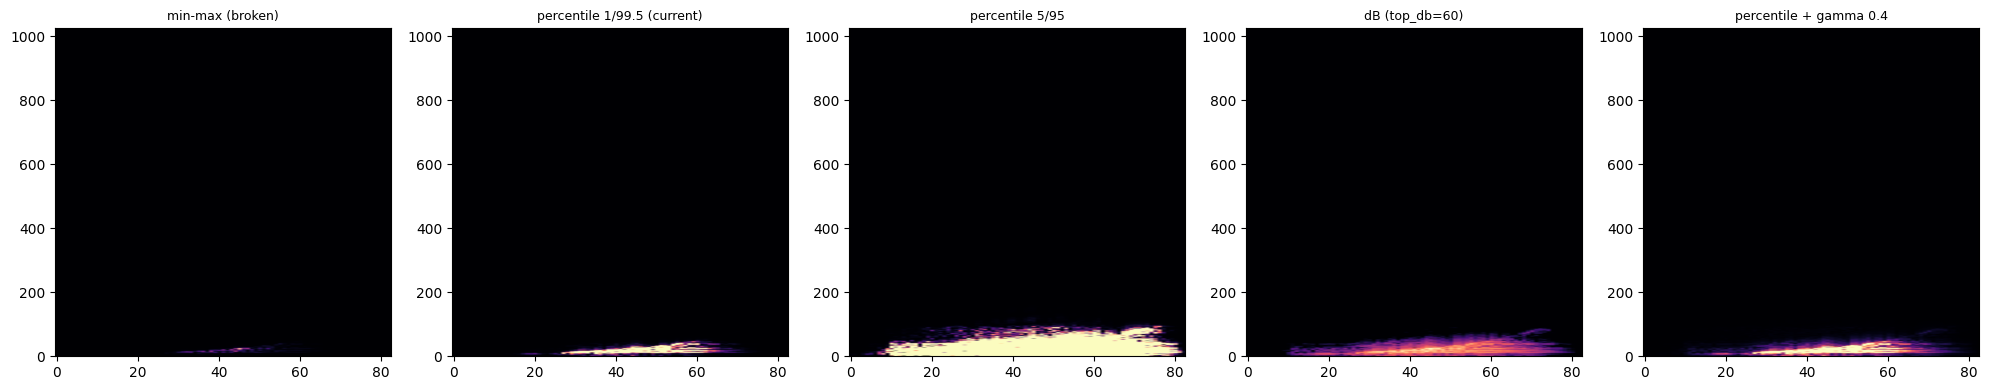

In [6]:
def stretch_minmax(x):
    lo, hi = x.min(), x.max()
    return np.clip((x - lo) / max(hi - lo, 1e-8), 0, 1)

def stretch_percentile(x, plo=1, phi=99.5):
    lo, hi = np.percentile(x, [plo, phi])
    return np.clip((x - lo) / max(hi - lo, 1e-8), 0, 1)

def stretch_db(x, top_db=60):
    db = 10 * np.log10(np.maximum(x, 1e-8))
    db -= db.max()
    return np.clip((db + top_db) / top_db, 0, 1)

def stretch_gamma(x, gamma=0.4):
    return stretch_percentile(x, 1, 99.5) ** gamma

variants = {
    "min-max (broken)": stretch_minmax(sm),
    "percentile 1/99.5 (current)": stretch_percentile(sm),
    "percentile 5/95": stretch_percentile(sm, 5, 95),
    "dB (top_db=60)": stretch_db(sm),
    "percentile + gamma 0.4": stretch_gamma(sm),
}

fig, axes = plt.subplots(1, len(variants), figsize=(4*len(variants), 4))
for ax, (name, v) in zip(axes, variants.items()):
    ax.imshow(v, cmap="magma", aspect="auto", origin="lower")
    ax.set_title(name, fontsize=9)
plt.tight_layout(); plt.show()

## 6. Colormap playground

Same (best) contrast stretch, different colormaps — purely cosmetic (model input is
unaffected), pick whichever makes structure clearest to your eye.

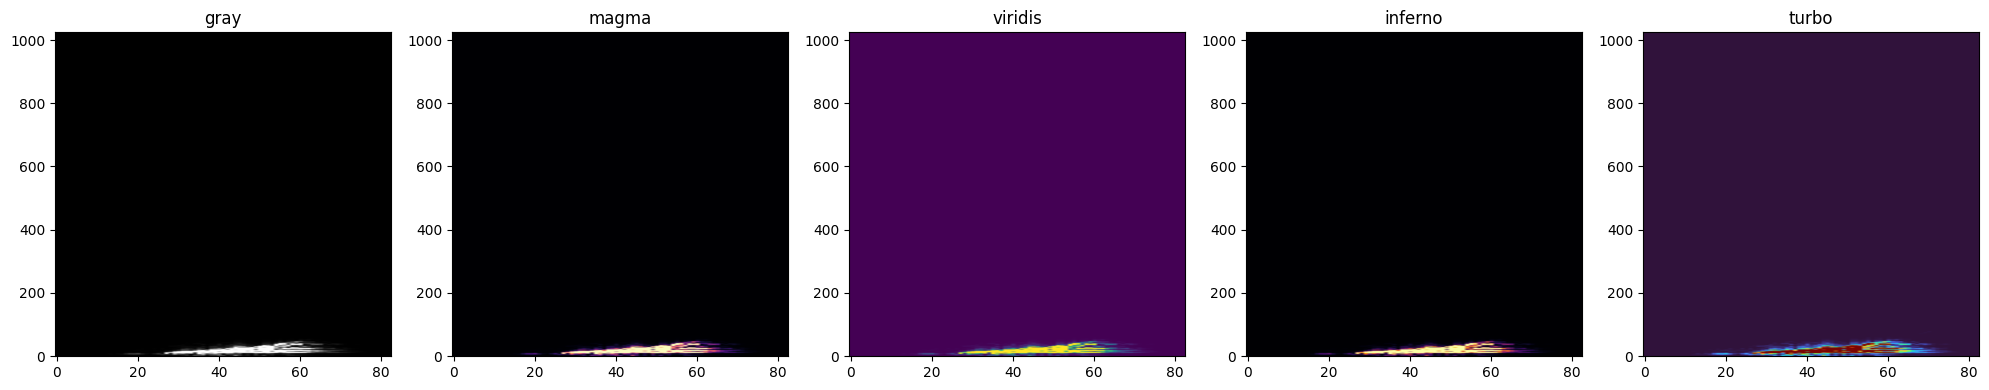

In [7]:
base = stretch_percentile(sm)
cmaps = ["gray", "magma", "viridis", "inferno", "turbo"]
fig, axes = plt.subplots(1, len(cmaps), figsize=(4*len(cmaps), 4))
for ax, cm in zip(axes, cmaps):
    ax.imshow(base, cmap=cm, aspect="auto", origin="lower")
    ax.set_title(cm)
plt.tight_layout(); plt.show()

## 7. STFT resolution playground (`nperseg`)

`spectrogram_map`'s time/freq resolution tradeoff — current default is `nperseg=512`
(chosen only so BEATs' patch conv gets >= 16 time frames on our ~3s recovered clip).
Larger `nperseg` = better freq resolution, fewer time frames; smaller = the opposite.

nperseg=  128 -> shape (257, 332)
nperseg=  256 -> shape (513, 167)
nperseg=  512 -> shape (1025, 83)
nperseg= 1024 -> shape (2049, 41)
nperseg= 2048 -> shape (4097, 20)


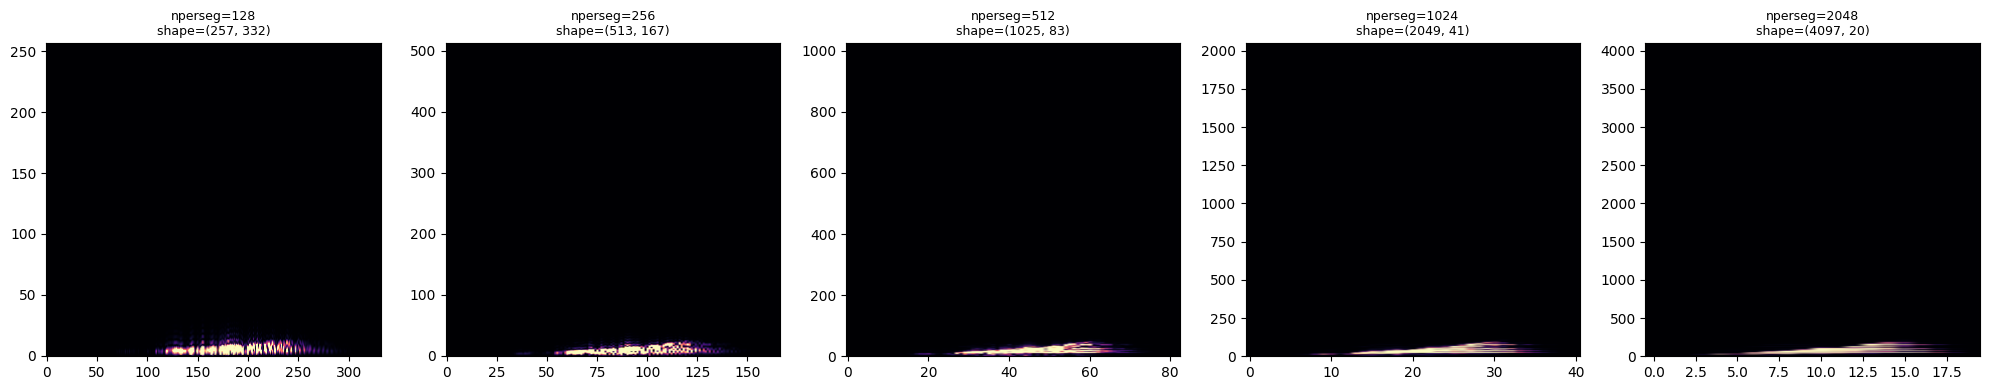

In [8]:
for nperseg in [128, 256, 512, 1024, 2048]:
    try:
        s = spectrogram_map(find_fft(cube_dir), fps=fps, nperseg=nperseg)
        print(f"nperseg={nperseg:5d} -> shape {s.shape}")
    except Exception as e:
        print(f"nperseg={nperseg:5d} -> ERROR: {e}")

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, nperseg in zip(axes, [128, 256, 512, 1024, 2048]):
    s = spectrogram_map(find_fft(cube_dir), fps=fps, nperseg=nperseg)
    ax.imshow(stretch_percentile(s), cmap="magma", aspect="auto", origin="lower")
    ax.set_title(f"nperseg={nperseg}\nshape={s.shape}", fontsize=9)
plt.tight_layout(); plt.show()

## 8. Interactive playground

Sliders for contrast (percentile range + gamma), colormap, and `nperseg`, applied live to
the spectrogram condition map for the cube sample. Only useful in a live Jupyter kernel
(not in a static nbviewer render).

In [ ]:
import ipywidgets as widgets
from ipywidgets import interact

_cache = {}
def _get_map(nperseg):
    if nperseg not in _cache:
        _cache[nperseg] = spectrogram_map(find_fft(cube_dir), fps=fps, nperseg=nperseg)
    return _cache[nperseg]

@interact(nperseg=widgets.SelectionSlider(options=[128, 256, 512, 1024, 2048], value=512),
          plo=widgets.FloatSlider(value=1, min=0, max=20, step=0.5),
          phi=widgets.FloatSlider(value=99.5, min=80, max=100, step=0.1),
          gamma=widgets.FloatSlider(value=1.0, min=0.2, max=2.0, step=0.05),
          cmap=widgets.Dropdown(options=["magma", "gray", "viridis", "inferno", "turbo"], value="magma"))
def _play(nperseg, plo, phi, gamma, cmap):
    s = _get_map(nperseg)
    v = stretch_percentile(s, plo, phi) ** gamma
    plt.figure(figsize=(8, 4))
    plt.imshow(v, cmap=cmap, aspect="auto", origin="lower")
    plt.title(f"nperseg={nperseg} pct=({plo},{phi}) gamma={gamma} cmap={cmap}")
    plt.xlabel("time frame"); plt.ylabel("freq bin")
    plt.show()

interactive(children=(SelectionSlider(description='nperseg', index=2, options=(128, 256, 512, 1024, 2048), val…

## 9. What actually reaches BEATs (`to_beats_fbank`)

The 128-freq-bin, z-scored `(T, 128)` tensor the model conditions on — visualized with a
diverging colormap centered at 0 (since it's z-scored, not a magnitude), to sanity-check it
still shows structure after resizing + normalization, not just noise.

fbank shape (T,128): (83, 128) mean/std: 2.872513e-09 0.9767862


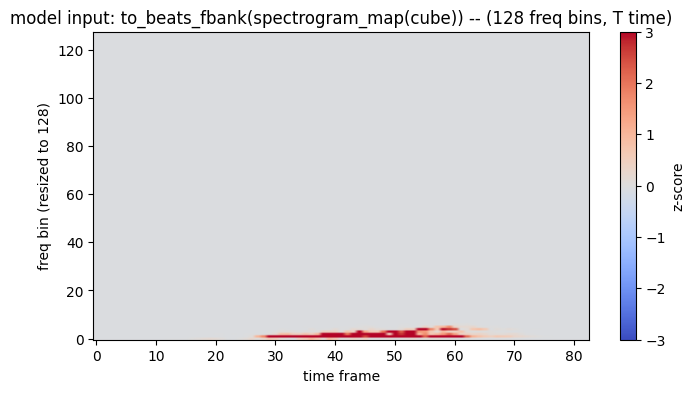

In [9]:
from src3.beats_input import to_beats_fbank

fbank = to_beats_fbank(sm).numpy()  # (T, 128)
print("fbank shape (T,128):", fbank.shape, "mean/std:", fbank.mean(), fbank.std())

plt.figure(figsize=(8, 4))
plt.imshow(fbank.T, cmap="coolwarm", aspect="auto", origin="lower", vmin=-3, vmax=3)
plt.colorbar(label="z-score")
plt.title("model input: to_beats_fbank(spectrogram_map(cube)) -- (128 freq bins, T time)")
plt.xlabel("time frame"); plt.ylabel("freq bin (resized to 128)")
plt.show()

## 10. Does our normalization actually match what BEATs expects?

"Matching their dataset" isn't a min/max question -- BEATs' own `preprocess()` normalizes
real audio's log-mel fbank by **fixed global constants** (`fbank_mean=15.41663,
fbank_std=6.55582`, computed once over AudioSet), not per-clip min/max or per-clip z-score:

```python
fbank = ta_kaldi.fbank(waveform * 2**15, num_mel_bins=128, ...)   # natural-log mel energies
fbank = (fbank - fbank_mean) / (2 * fbank_std)
```

Measured directly below: what does a real fbank look like in absolute scale, before and
after that normalization -- and how does that compare to what our current
`to_beats_fbank()` (per-sample z-score, forcing std=1.0 on every single sample) produces?

In [10]:
import torchaudio.compliance.kaldi as ta_kaldi
import torch

# a real fbank's absolute scale, and what BEATs' own fixed-constant normalization does to it
_wav = torch.randn(16000) * 0.01  # arbitrary quiet 1s waveform at 16kHz, just to see the scale
_real_fbank = ta_kaldi.fbank((_wav * 2**15).unsqueeze(0), num_mel_bins=128, sample_frequency=16000,
                              frame_length=25, frame_shift=10)
FBANK_MEAN, FBANK_STD = 15.41663, 6.55582
_real_norm = (_real_fbank - FBANK_MEAN) / (2 * FBANK_STD)
print("real fbank (raw):        mean %.3f std %.3f" % (_real_fbank.mean(), _real_fbank.std()))
print("real fbank (BEATs norm): mean %.3f std %.3f  <-- this is the scale the pretrained conv actually expects" %
      (_real_norm.mean(), _real_norm.std()))

_ours = to_beats_fbank(sm)
print("ours (per-sample z-score): mean %.3f std %.3f  <-- forced to std=1.0 regardless of content" %
      (_ours.mean(), _ours.std()))
print()
print("our current normalization is ~%.1fx too large in scale vs. what BEATs' pretrained conv saw in training"
      % (_ours.std() / _real_norm.std()))

real fbank (raw):        mean 15.245 std 4.272
real fbank (BEATs norm): mean -0.013 std 0.326  <-- this is the scale the pretrained conv actually expects
ours (per-sample z-score): mean -0.000 std 0.977  <-- forced to std=1.0 regardless of content

our current normalization is ~3.0x too large in scale vs. what BEATs' pretrained conv saw in training


**Takeaway:** don't use min/max (already known-bad -- that's the original black-panel
bug), but per-sample z-score isn't quite right either -- it forces every sample's std to
1.0 regardless of how much real signal it has, and lands ~3x larger in scale than what the
pretrained conv actually saw during training. What's "usually done" (and what BEATs itself
does) is normalize by **global dataset statistics** computed once, not per-sample -- so a
near-silent sample and a loud one aren't both artificially stretched to look equally
"informative". The cell below computes that as an alternative.

global spectrogram_map stats over 40 samples: mean=0.0000 std=0.0001
global-normalized fbank: mean -0.003 std 0.262 (target ~0.32, matching real BEATs input)


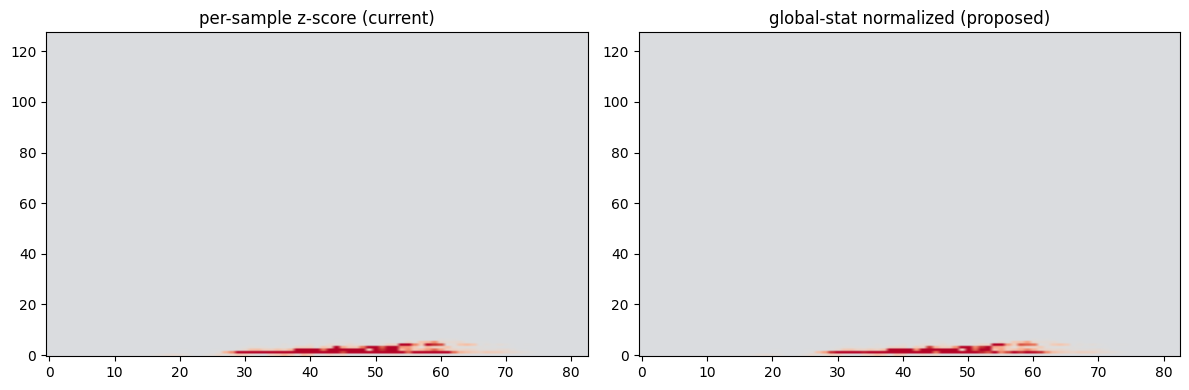

In [11]:
def to_beats_fbank_global(cond_map, target_freq_bins=128, global_mean=None, global_std=None,
                            beats_std_target=6.55582 * 2):
    """Same resize+transpose as to_beats_fbank, but normalized by fixed global stats
    (computed once over a sample of the dataset, passed in) instead of this one sample's
    own mean/std -- mirrors BEATs.preprocess's own fixed-constant scheme, and rescaled so
    the resulting std lands near what real fbanks have after BEATs' own normalization
    (~0.32, measured above), not the arbitrary std=1.0 our current per-sample z-score forces."""
    import torch.nn.functional as tf
    t = torch.from_numpy(cond_map).float()[None, None]
    t = tf.interpolate(t, size=(target_freq_bins, cond_map.shape[1]), mode="bilinear", align_corners=False)
    t = t[0, 0].T
    return (t - global_mean) / global_std * 0.32

# estimate global stats from a sample of gastronorm spectrogram_maps (not the whole set -- just enough to compare)
import random
random.seed(0)
subset = random.sample(samples, min(40, len(samples)))
all_vals = []
for d, m in subset:
    try:
        s = spectrogram_map(find_fft(d), fps=float(m["fps"]))
        all_vals.append(s.ravel())
    except Exception:
        pass
all_vals = np.concatenate(all_vals)
GLOBAL_MEAN, GLOBAL_STD = all_vals.mean(), all_vals.std()
print(f"global spectrogram_map stats over {len(subset)} samples: mean={GLOBAL_MEAN:.4f} std={GLOBAL_STD:.4f}")

fbank_global = to_beats_fbank_global(sm, global_mean=GLOBAL_MEAN, global_std=GLOBAL_STD)
print("global-normalized fbank: mean %.3f std %.3f (target ~0.32, matching real BEATs input)" %
      (fbank_global.mean(), fbank_global.std()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(to_beats_fbank(sm).numpy().T, cmap="coolwarm", aspect="auto", origin="lower", vmin=-3, vmax=3)
axes[0].set_title("per-sample z-score (current)")
axes[1].imshow(fbank_global.numpy().T, cmap="coolwarm", aspect="auto", origin="lower", vmin=-1, vmax=1)
axes[1].set_title("global-stat normalized (proposed)")
plt.tight_layout(); plt.show()

## 11. dB scale vs. `log1p` -- matching the repo's existing spectrogram convention

`spectrogram_map()` currently uses `log1p(Sxx)`. Elsewhere in this repo
(`utils/viz.py:_draw_spectrogram`, used by `plot_spectrogram`/`make_spectrogram_video`) the
established convention for displaying a spectrogram is **dB scale**,
`10 * np.log10(Sxx + 1e-10)`, with a `viridis` colormap -- that's very likely "the technique
I created elsewhere" you're thinking of. Compare them directly on the same underlying STFT.

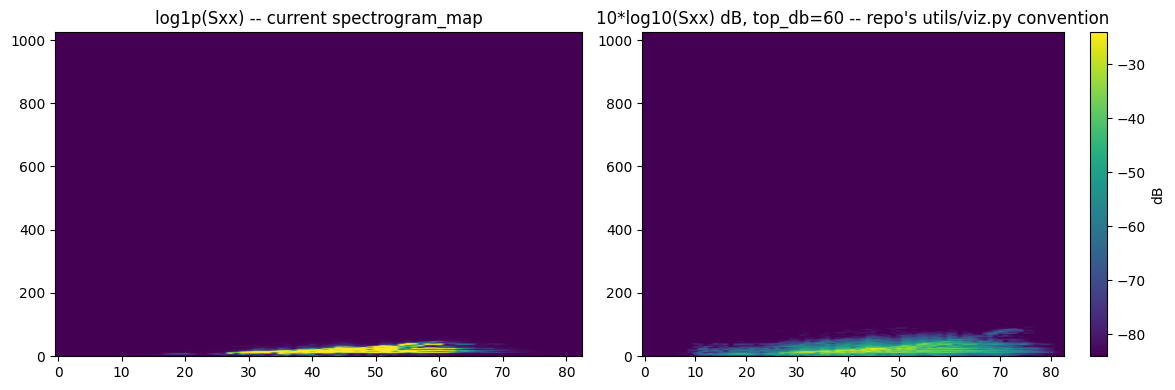

log1p_map  min/max/std: 0.0 0.003909283 4.7336518e-05
db_map     min/max/std: -100.00001 -24.07054 9.279257


In [12]:
from scipy.signal import spectrogram as scipy_spectrogram

# reuse the same recovered-audio path spectrogram_map uses internally, but keep the raw Sxx
# (not log1p'd) so we can apply either convention ourselves
fft, _, n_samples = _load_fft(find_fft(cube_dir))
avg_spectrum = fft.mean(axis=(0, 2)).astype(np.complex64)
full_freqs = np.fft.rfftfreq(n_samples, d=1.0 / fps)
mask = (full_freqs >= MIN_FREQ) & (full_freqs <= MAX_FREQ)
spectrum = np.zeros(len(full_freqs), dtype=np.complex64)
spectrum[mask] = avg_spectrum
signal = np.fft.irfft(spectrum, n=n_samples)
audio = resample(signal, int(22050 * len(signal) / fps))
audio = audio / (np.max(np.abs(audio)) + 1e-8)
freqs_s, times_s, Sxx = scipy_spectrogram(audio.astype(np.float32), fs=22050, nperseg=512, noverlap=512//3, nfft=512*4)

log1p_map = np.log1p(Sxx)                      # current spectrogram_map
db_map = 10 * np.log10(Sxx + 1e-10)            # utils/viz.py's own convention

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(stretch_percentile(log1p_map), cmap="viridis", aspect="auto", origin="lower")
axes[0].set_title("log1p(Sxx) -- current spectrogram_map")
im = axes[1].imshow(db_map, cmap="viridis", aspect="auto", origin="lower", vmin=db_map.max()-60, vmax=db_map.max())
axes[1].set_title("10*log10(Sxx) dB, top_db=60 -- repo's utils/viz.py convention")
fig.colorbar(im, ax=axes[1], label="dB")
plt.tight_layout(); plt.show()

print("log1p_map  min/max/std:", log1p_map.min(), log1p_map.max(), log1p_map.std())
print("db_map     min/max/std:", db_map.min(), db_map.max(), db_map.std())

## Summary / recommendation

- **Min/max normalization:** no -- already known-bad (the original black-panel bug), and
  doesn't resemble anything BEATs does.
- **Per-sample z-score (current `to_beats_fbank`):** works, but forces std=1.0 on every
  sample regardless of content and lands ~3x larger in scale than real BEATs input
  (measured above: real ≈0.32 std after BEATs' own normalization vs. ours =1.0).
- **What's usual / what BEATs itself does:** normalize by **fixed global statistics**
  (mean/std computed once across many samples, not per-sample) -- section 10 above computes
  this for `spectrogram_map` and rescales to land near BEATs' real ~0.32 std.
- **Spectrogram construction:** switch `log1p(Sxx)` to the repo's own **dB** convention
  (`10*log10(Sxx+eps)`, `utils/viz.py`'s formula) -- section 11 shows it side by side; if it
  reads as clearly more detailed, that's the one to standardize on.

None of this is applied to `src3/beats_input.py` yet -- this notebook is for comparing
options before committing to one. Tell me which combination looks best and I'll wire it
into `beats_input.py`'s `spectrogram_map`/`to_beats_fbank` (global stats would need to be
computed once over the actual training split and hardcoded/cached, similar to how
`LOG_CONTRAST_K` is already a tuned constant there).